# 2.1 Modern Portfolio Theory
Modern portfolio theory also popularly called Mean-Variance Portfolio Theory (MVP) is a major breakthrough in finance. It is based on the premise that returns are normally distributed and by looking at mean and variance, we can essentially describe the distribution of end-of-period wealth.

The basic idea of this theory is to achieve diversification by constructing a portfolio for a minimal portfolio risk or maximal portfolio returns. Accordingly, the **Efficient Frontier** is a set of optimal portfolios in the risk-return spectrum, and portfolios located under the Efficient Frontier curve are considered sub-optimal.

This means that the portfolios on the frontier offered

- `Highest expected return for a given level of risk`

- `Lowest level of risk for a given level of expected returns`

In essence, the investors' goal should be to select a level of risk that he/she is comfortable with and then find a portfolio that maximizes returns based on the selected risk level.

## 2.1.1 Import libraries

In [1]:
# Import pandas and yfinance
import pandas as pd
import yfinance as yf

# Import numpy
import numpy as np
from numpy import *
from numpy.linalg import multi_dot

# Plot settings
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.figsize'] = 16, 8

We will use the FAANG stocks as before to build our portfolio.

In [2]:
# FAANG stocklist
symbols = ['AAPL', 'AMZN', 'META', 'GOOG', 'NFLX' ]

# Number of assets
numofasset = len(symbols)

# Number of portfolio for optimization
numofportfolio = 5000

## 2.1.2 Retrive Data

In [3]:
# Fetch data from yahoo finance for last six years
faangstocks = yf.download(symbols, start='2015-01-01', end='2021-07-22', progress=False)['Close']

# Verify the output
faangstocks.tail()

YF.download() has changed argument auto_adjust default to True


Ticker,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2021-07-15,145.495880,181.559998,130.796539,343.149170,542.950012
2021-07-16,143.447876,178.681503,131.373474,339.861786,530.309998
2021-07-19,139.587067,177.479507,128.791229,335.667786,532.280029
2021-07-20,143.212692,178.659500,130.632126,340.359833,531.049988
2021-07-21,142.477768,179.259995,132.125748,344.912476,513.630005


In [4]:
# Let's save the data for future use
faangstocks.to_csv('faang_stocks.csv')

In [5]:
# Load locally stored data
df = pd.read_csv('faang_stocks.csv', index_col=0, parse_dates=True)

# Check first 5 values
df.head()

,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2015-01-02,24.320433,15.4260,26.074963,78.151459,49.848572
2015-01-05,23.635284,15.1095,25.531416,76.896271,47.311428
2015-01-06,23.637514,14.7645,24.939672,75.860214,46.501431
2015-01-07,23.968956,14.9210,24.896942,75.860214,46.742859
2015-01-08,24.889896,15.0230,24.975445,77.882492,47.779999


## 2.1.3 Descriptive Statistics

In [6]:
summary = df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
AAPL,1649.0,52.536647,33.108114,20.674534,27.752827,40.772720,62.717976,146.152420
AMZN,1649.0,76.850783,46.283692,14.347500,37.888500,75.614502,95.449501,186.570496
GOOG,1649.0,55.343670,22.632903,24.472139,38.214691,52.841133,62.934368,132.125748
META,1649.0,169.658187,63.341051,73.768211,119.413849,167.041901,196.061050,354.286652
NFLX,1649.0,265.913408,152.497783,45.547142,115.809998,275.299988,368.149994,586.340027


## 2.1.4 Visualize Data

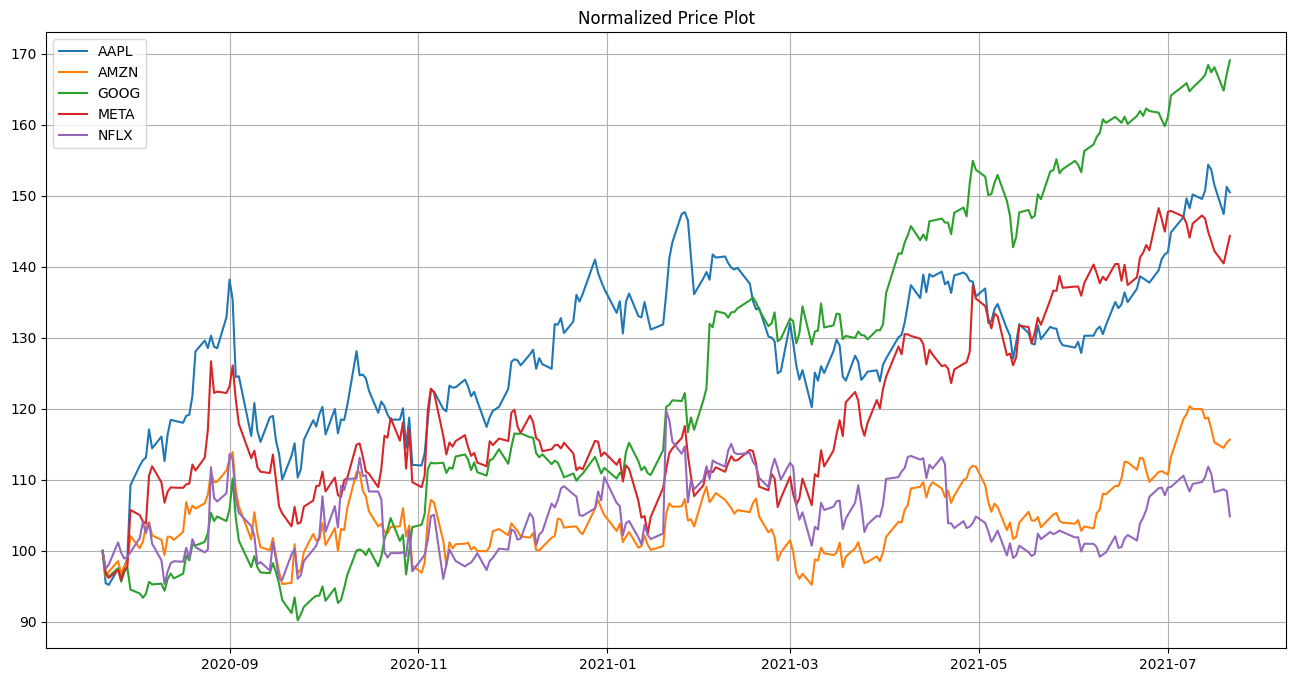

In [7]:
# Visualize the data
fig = plt.figure(figsize=(16,8))
ax = plt.axes()
ax.set_title('Normalized Price Plot')
ax.plot(df[-252:]/df.iloc[-252] * 100)
ax.legend(df.columns, loc='upper left')
ax.grid(True)

## 2.1.5 Calculate Returns

In [8]:
# Calculate returns
returns = df.pct_change().fillna(0)
returns.head()

,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2015-01-02,0.000000,0.000000,0.000000,0.000000,0.000000
2015-01-05,-0.028172,-0.020517,-0.020846,-0.016061,-0.050897
2015-01-06,0.000094,-0.022833,-0.023177,-0.013473,-0.017121
2015-01-07,0.014022,0.010600,-0.001713,0.000000,0.005192
2015-01-08,0.038422,0.006836,0.003153,0.026658,0.022188


### 2.1.5.1 Annualized Returns

In **MVP**, the average returns play an important role as they are used to approximate the expected returns.

In [9]:
# Calculate annual returns
annual_returns = (returns.mean() * 252)
annual_returns

AAPL    0.313659
AMZN    0.420956
GOOG    0.283826
META    0.277351
NFLX    0.443783
dtype: float64

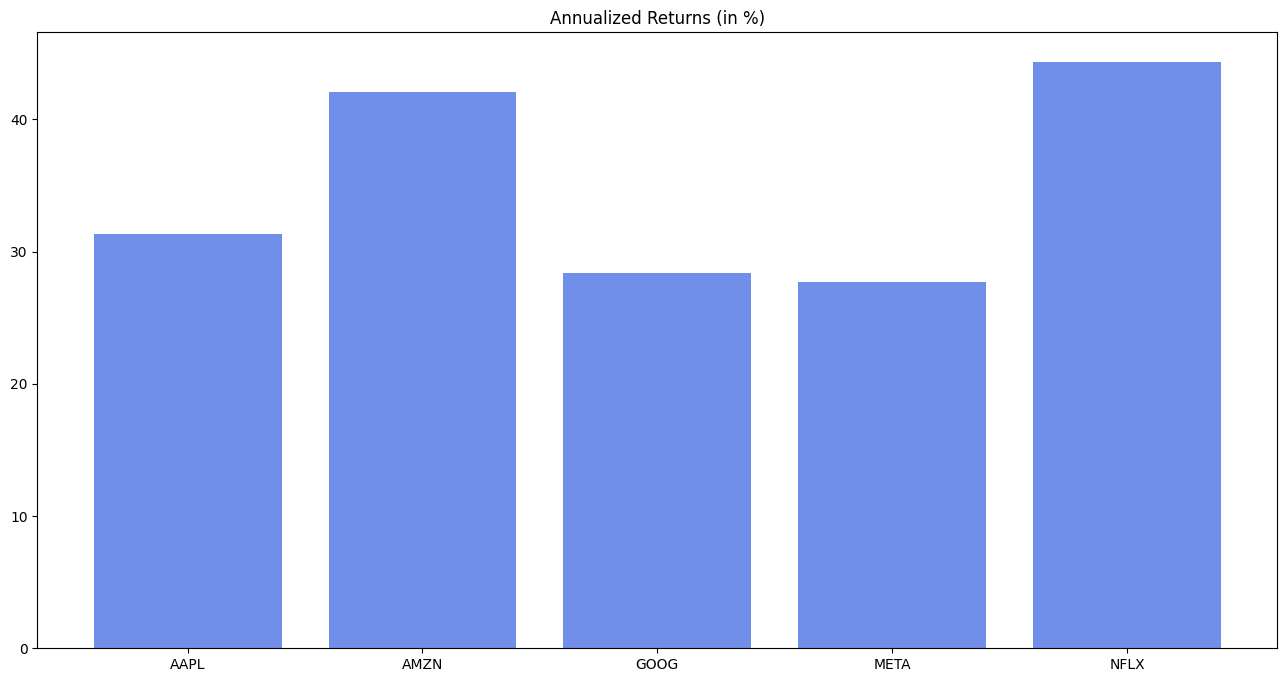

In [10]:
# Visualize the data
fig = plt.figure()
ax =plt.axes()
ax.bar(annual_returns.index, annual_returns*100, color='royalblue', alpha=0.75)
ax.set_title('Annualized Returns (in %)');

## 2.1.6 Calculate Volatility

In [11]:
vols = returns.std()
vols

AAPL    0.018543
AMZN    0.019172
GOOG    0.016884
META    0.019943
NFLX    0.026455
dtype: float64

### 2.1.6.1 Annualized Volatilities

In [12]:
# Calculate annualized volatilities
annual_vols = vols*sqrt(252)
annual_vols

AAPL    0.294356
AMZN    0.304340
GOOG    0.268033
META    0.316592
NFLX    0.419954
dtype: float64

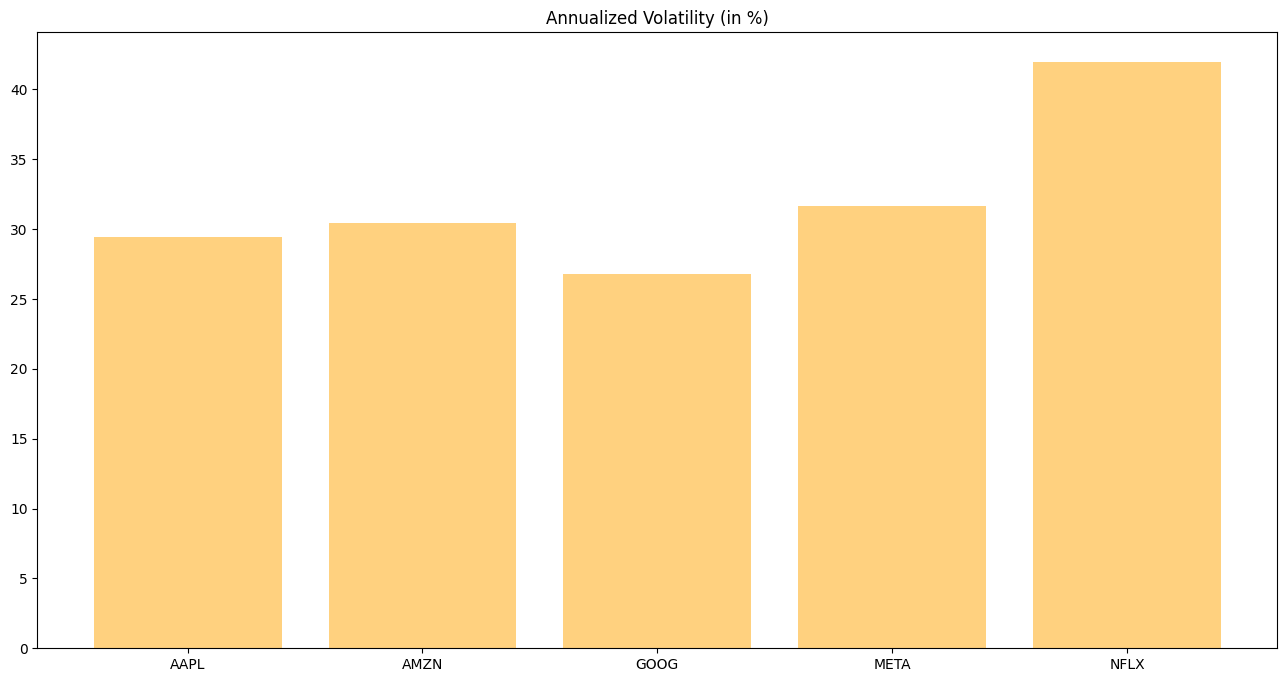

In [13]:
# Visualize the data
fig = plt.figure()
ax = plt.axes()
ax.bar(annual_vols.index, annual_vols*100, color='orange', alpha=0.5)
ax.set_title('Annualized Volatility (in %)');

# 2.2 Portfolio Statistics
Consider a portfolio that is fully invested in risky assets. Let $w$ and $\mu$ be the vector of weights and mean returns of $n$ assets.

$$
w = \begin{pmatrix} 
w_1 \\ 
w_2 \\ 
\vdots \\ 
w_n 
\end{pmatrix}, \quad
\mu = \begin{pmatrix} 
\mu_1 \\ 
\mu_2 \\ 
\vdots \\ 
\mu_n 
\end{pmatrix},
$$

where $\sum_{i=1}^{n} w_i = 1$.

### **Expected Portfolio Return**

Expected Portfolio Return is the dot product of the weights and expected returns:

$$
\mu_\pi = w^T \cdot \mu,
$$

which is also equivalent to:

$$
\mu_\pi = \sum_{i=1}^{n} w_i \mu_i.
$$

### **Expected Portfolio Variance**

Expected Portfolio Variance is computed as the quadratic form of the weights and the covariance matrix:

$$
\sigma^2_\pi = w^T \cdot \Sigma \cdot w,
$$

where $\Sigma$ \Sigma = \begin{pmatrix}
\sigma_{1,1} & \sigma_{1,2} & \cdots & \sigma_{1,n} \\
\sigma_{2,1} & \sigma_{2,2} & \cdots & \sigma_{2,n} \\
\vdots & \vdots & \ddots & \vdots \\
\sigma_{n,1} & \sigma_{n,2} & \cdots & \sigma_{n,n}
\end{pmatrix}gmarix}
{n,2} & \cdots & \sigma_{n,n} 
\end{pmatrix}.
$$
{n,2} & \cdots & \sigma_{n,n} 
\end{pmatrix}.
$$
 \right) $$

## 2.2.1 Equal Weighted Portfolio

Assume a portoflio composed of all five stocks with equal weighting. We will now calculate the portfolio statistics.

In [14]:
wts = numofasset * [1./numofasset]
wts

[0.2, 0.2, 0.2, 0.2, 0.2]

In [15]:
array(wts).shape

(5,)

In [16]:
wts = numofasset * [1./numofasset]
wts = array(wts)[:,newaxis]
wts

array([[0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2]])

In [17]:
wts.shape

(5, 1)

## 2.2.2 Portfolio Return

In [18]:
ret = array(returns.mean()*252)[:,newaxis]
ret

array([[0.3136589 ],
       [0.42095605],
       [0.28382552],
       [0.27735088],
       [0.44378319]])

In [19]:
ret.shape

(5, 1)

In [20]:
# Portfolio returns
wts.T @ ret

array([[0.34791491]])

## 2.2.3 Portfolio Volatility

In [21]:
# Covariance matrix
cov = returns.cov() * 252
cov

,AAPL,AMZN,GOOG,META,NFLX
AAPL,0.086646,0.050035,0.047473,0.053710,0.051414
AMZN,0.050035,0.092623,0.052610,0.057754,0.067641
GOOG,0.047473,0.052610,0.071842,0.056447,0.054014
META,0.053710,0.057754,0.056447,0.100231,0.059243
NFLX,0.051414,0.067641,0.054014,0.059243,0.176361


In [22]:
# Portfolio variance
var = multi_dot([wts.T, cov, wts])
var

array([[0.06513533]])

In [23]:
# Portfolio volatility
sqrt(var)

array([[0.25521623]])

## 2.2.4 Portfolio statistics

Let's subsume key statistics into a function which can be used for optimization exercise.

In [24]:
def portfolio_stats(weights):
    
    weights = array(weights)[:,newaxis]
    port_rets = weights.T @ array(returns.mean() * 252)[:,newaxis]
    port_vols = sqrt(multi_dot([weights.T, returns.cov() * 252, weights]))
    
    return np.array([port_rets, port_vols, port_rets/port_vols]).flatten()

# 2.3 Portfolio Simulation

Now, we will implement a Monte Carlo simulation to generate random portfolio weights on a larger scale and calculate the expected portfolio return, variance and sharpe ratio for every simulated allocation. We will then identify the portfolio with a highest return for per unit of risk.

In [25]:
w = random.random(numofasset)[:, newaxis]
w

array([[0.6393766 ],
       [0.95894065],
       [0.13684851],
       [0.30124648],
       [0.24656282]])

In [26]:
# Set weights such that sum of weights equals 1
w /= sum(w)
w

array([[0.28006289],
       [0.42003992],
       [0.05994306],
       [0.13195347],
       [0.10800066]])

In [27]:
# Initialize the lists
rets = []; vols = []; wts = []


# Simulate 5,000 portfolios
for i in range (5000):
    
    # Generate random weights
    weights = random.random(numofasset)[:, newaxis]
    
    # Set weights such that sum of weights equals 1
    weights /= sum(weights)
    
    # Portfolio statistics
    rets.append(weights.T @ array(returns.mean() * 252)[:, newaxis])
    vols.append(sqrt(multi_dot([weights.T, returns.cov()*252, weights])))
    wts.append(weights.flatten())


# Record values
port_rets = array(rets).flatten()
port_vols = array(vols).flatten()
port_wts = array(wts)

In [28]:
port_rets

array([0.3402505 , 0.37655934, 0.37665147, ..., 0.31900349, 0.37647644,
       0.36356631])

In [29]:
port_vols

array([0.25433778, 0.28857856, 0.2687779 , ..., 0.25586831, 0.26488649,
       0.28072437])

In [30]:
port_wts

array([[0.24651677, 0.14181054, 0.1972776 , 0.22027977, 0.19411532],
       [0.23647315, 0.08185891, 0.18527015, 0.02973561, 0.46666218],
       [0.08508555, 0.36475939, 0.11643759, 0.17489705, 0.25882042],
       ...,
       [0.12676084, 0.07400812, 0.30205733, 0.35016791, 0.1470058 ],
       [0.24009052, 0.31142154, 0.12022358, 0.05843569, 0.26982866],
       [0.00904011, 0.14476149, 0.23810648, 0.22621265, 0.38187927]])

In [31]:
port_rets.shape, port_vols.shape, port_wts.shape

((5000,), (5000,), (5000, 5))

In [32]:
# Create a dataframe for analysis
msrp_df = pd.DataFrame({'returns': port_rets,
                        'volatility': port_vols,
                        'sharpe_ratio': port_rets/port_vols,
                        'weights': list(port_wts)})
msrp_df.head()

,returns,volatility,sharpe_ratio,weights
0,0.340251,0.254338,1.337790,"[0.2465167734880256, 0.14181053959328138, 0.19..."
1,0.376559,0.288579,1.304876,"[0.23647315178589418, 0.0818589075634785, 0.18..."
2,0.376651,0.268778,1.401348,"[0.0850855467496317, 0.36475939495063264, 0.11..."
3,0.357960,0.258088,1.386972,"[0.05528243155627929, 0.3105303745228902, 0.30..."
4,0.358312,0.263235,1.361186,"[0.10704190022215983, 0.23065741526266212, 0.1..."


## 2.3.1 Summary Statistics

In [33]:
# Summary Statistics
msrp_df.describe().T

,count,mean,std,min,25%,50%,75%,max
returns,5000.0,0.347868,0.019782,0.288496,0.335095,0.347908,0.360724,0.421900
volatility,5000.0,0.261200,0.010850,0.244566,0.253351,0.259068,0.266697,0.332326
sharpe_ratio,5000.0,1.332061,0.058316,1.056940,1.296763,1.337532,1.375383,1.456720


## 2.3.2 Maximum Sharpe Ratio Portfolio

In [34]:
# Max sharpe ratio portfolio
msrp = msrp_df.iloc[msrp_df['sharpe_ratio'].idxmax()]
msrp

returns                                                  0.390209
volatility                                               0.267868
sharpe_ratio                                              1.45672
weights         [0.27135888489444737, 0.4927628981196458, 0.01...
Name: 3221, dtype: object

In [35]:
# Max sharpe ratio portfolio weights
max_sharpe_port_wts = msrp_df['weights'][msrp_df['sharpe_ratio'].idxmax()]

# Allocation to achieve max sharpe ratio portfolio
dict(zip(symbols,np.around(max_sharpe_port_wts*100,2)))

{'AAPL': 27.14, 'AMZN': 49.28, 'META': 1.37, 'GOOG': 2.9, 'NFLX': 19.32}

## 2.3.3 Visulaize Simulated Portfolio

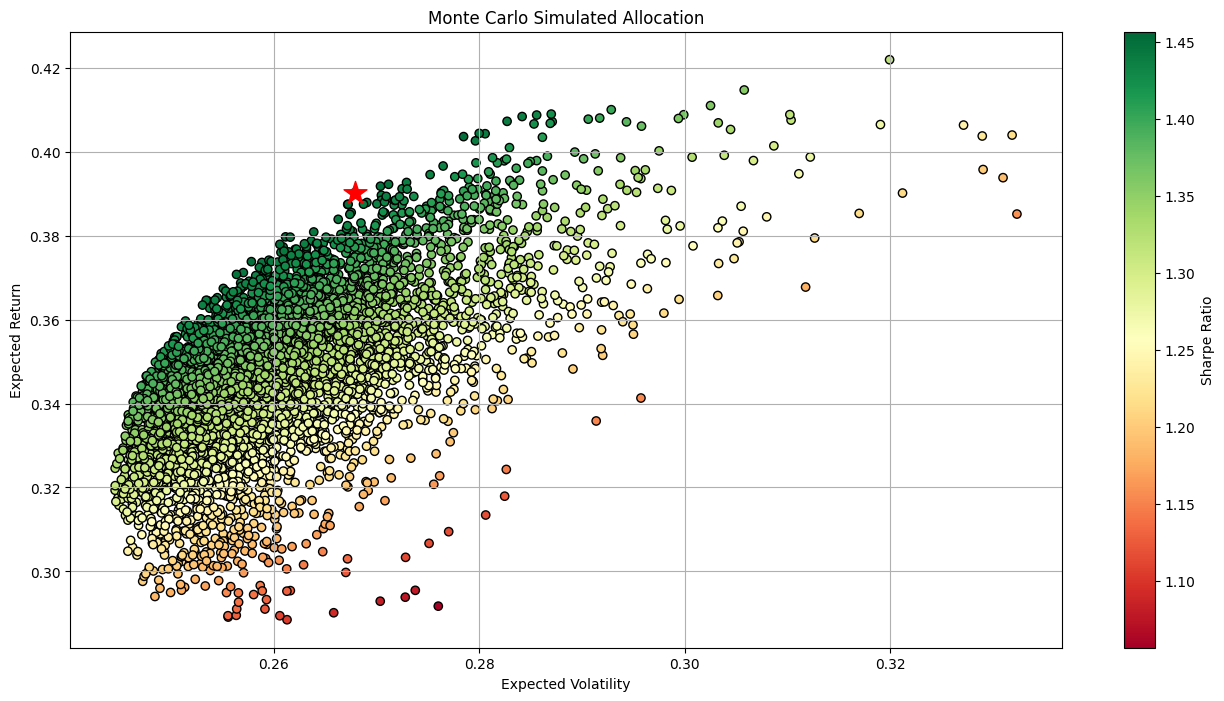

In [36]:
# Visualize the simulated portfolio for risk and return
fig = plt.figure()
ax = plt.axes()
ax.set_title('Monte Carlo Simulated Allocation')

# Simulated portfolios
fig.colorbar(ax.scatter(port_vols, port_rets, c=port_rets / port_vols,
                        marker='o', cmap='RdYlGn', edgecolors='black'), label='Sharpe Ratio')

# Maximum sharpe ratio portfolio
ax.scatter(msrp['volatility'], msrp['returns'], c='red', marker='*', s = 300, label='Max Sharpe Ratio')

ax.set_xlabel('Expected Volatility')
ax.set_ylabel('Expected Return')
ax.grid(True)

# 2.4 Efficient Frontier

The Efficient Frontier is formed by a set of portfolios offering the highest expected portfolio return for a certain volatility or offering the lowest
volatility for a certain level of expected returns.
Return objective:
$$\underset{w_1,w_2,\dots,w_n}{minimize} \space\space \sigma^2_{p}(w_1,w_2,\dots,w_n)$$
subject to,
$$E[R_p] = m$$
Risk constraint:
$$\underset{w_1,w_2,\dots,w_n}{maximize} \space\space E[R_p(w_1,w_2,\dots,w_n)]$$
subject to,
$$\sigma^2_{p}(w_1,w_2,\dots,w_n)=v^2$$
where, $\sum_{i=1}^{n}w_i=1$ for the above objectives.
We can use numerical optimization to achieve this objective. The goal of optimization is to find the optimal value of the objective function by
adjusting the target variables operating withing some boundary conditions and constraints.

## 2.4.1 Constrained Optimization

Construction of optimal portfolios is a constrained optimization problem where we specify some boundary conditions and constraints. The objective function here is a function returning maximum Sharpe ratio, minimum variance (volatility) and the target variables are portfolio weights. We will use the `minimize` function from `scipy` optimization module to achieve our objective.

```python
sco.minimize(
    fun,
    x0,
    args=(),
    method=None,
    jac=None,
    hess=None,
    hessp=None,
    bounds=None,
    constraints=(),
    tol=None,
    callback=None,
   options=None
)
tions=None
)

In [37]:
# Import optimization module from scipy
import scipy.optimize as sco

### 2.4.1.1 Maximum sharpe ratio portfolio

In [38]:
# Maximizing sharpe ratio
def min_sharpe_ratio(weights):
    return -portfolio_stats(weights)[2]

In [39]:
# Each asset boundary ranges from 0 to 1
tuple((0, 1) for x in range(numofasset))

((0, 1), (0, 1), (0, 1), (0, 1), (0, 1))

In [40]:
cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bnds = tuple((0, 1) for x in range(numofasset))
initial_wts = numofasset*[1./numofasset]

In [41]:
# Optimizing for maximum sharpe ratio
opt_sharpe = sco.minimize(min_sharpe_ratio, initial_wts, method='SLSQP', bounds=bnds, constraints=cons)

In [42]:
opt_sharpe

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -1.4650660044912935
       x: [ 2.132e-01  5.804e-01  3.742e-02  0.000e+00  1.690e-01]
     nit: 6
     jac: [-2.210e-04  3.457e-05  9.269e-06  1.162e-01  1.579e-04]
    nfev: 36
    njev: 6

In [43]:
# Portfolio weights
list(zip(symbols,np.around(opt_sharpe['x']*100, 2)))

[('AAPL', 21.32),
 ('AMZN', 58.04),
 ('META', 3.74),
 ('GOOG', 0.0),
 ('NFLX', 16.9)]

In [44]:
# Portfolio stats
stats = ['Returns', 'Volatility', 'Sharpe Ratio']
list(zip(stats,np.around(portfolio_stats(opt_sharpe['x']),4)))

[('Returns', 0.3968), ('Volatility', 0.2708), ('Sharpe Ratio', 1.4651)]

### 2.4.1.2 Minumum variance portfolio

In [45]:
# Minimize the variance
def min_variance(weights):
    return portfolio_stats(weights)[1]**2

In [46]:
# Optimizing for minimum variance
opt_var = sco.minimize(min_variance, initial_wts, method='SLSQP', bounds=bnds, constraints=cons)

In [47]:
opt_var

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.05971832086061597
       x: [ 2.837e-01  1.742e-01  4.257e-01  8.608e-02  3.028e-02]
     nit: 13
     jac: [ 1.194e-01  1.195e-01  1.194e-01  1.195e-01  1.196e-01]
    nfev: 78
    njev: 13

In [48]:
# Portfolio weights
list(zip(symbols,np.around(opt_var['x']*100,2)))

[('AAPL', 28.37),
 ('AMZN', 17.42),
 ('META', 42.57),
 ('GOOG', 8.61),
 ('NFLX', 3.03)]

In [49]:
# Portfolio stats
list(zip(stats,np.around(portfolio_stats(opt_var['x']),4)))

[('Returns', 0.3205), ('Volatility', 0.2444), ('Sharpe Ratio', 1.3114)]

### 2.4.1.3 Efficient Frontier portfolio

For efficient frontier portfolios, we fix a target return and derive for objective function.

In [50]:
# Minimize the volatility
def min_volatility(weights):
    return portfolio_stats(weights)[1]

In [51]:
targetrets = linspace(0.28,0.44,100)
tvols = []

for tr in targetrets:

    ef_cons = ({'type': 'eq', 'fun': lambda x: portfolio_stats(x)[0] - tr}, 
               {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    opt_ef = sco.minimize(min_volatility, initial_wts, method='SLSQP', bounds=bnds, constraints=ef_cons)
    tvols.append(opt_ef['fun'])

targetvols = array(tvols)

In [52]:
targetvols

array([0.27259725, 0.26120163, 0.25776736, 0.25485072, 0.25243574,
       0.25053695, 0.24916613, 0.24833188, 0.24787798, 0.24746264,
       0.24707486, 0.24671477, 0.24638248, 0.24607813, 0.24580179,
       0.24555318, 0.24532939, 0.2451284 , 0.24495069, 0.2447973 ,
       0.24466685, 0.24456072, 0.24447836, 0.24441979, 0.24438501,
       0.24437401, 0.24438678, 0.24442331, 0.24448348, 0.2445672 ,
       0.24467519, 0.24480646, 0.24496178, 0.24514076, 0.24534333,
       0.24556944, 0.24581903, 0.24609203, 0.24638835, 0.24670795,
       0.24705081, 0.2474168 , 0.24780544, 0.24821712, 0.24865131,
       0.24910789, 0.2495873 , 0.25009017, 0.2506191 , 0.25117357,
       0.25175294, 0.25235805, 0.25298816, 0.25364335, 0.25432303,
       0.2550273 , 0.25575839, 0.25651116, 0.25728697, 0.25808843,
       0.25891028, 0.25975712, 0.26062714, 0.26152016, 0.26243594,
       0.26337425, 0.26433487, 0.26531755, 0.26632206, 0.267344  ,
       0.26838971, 0.26945683, 0.27054391, 0.27165181, 0.27278

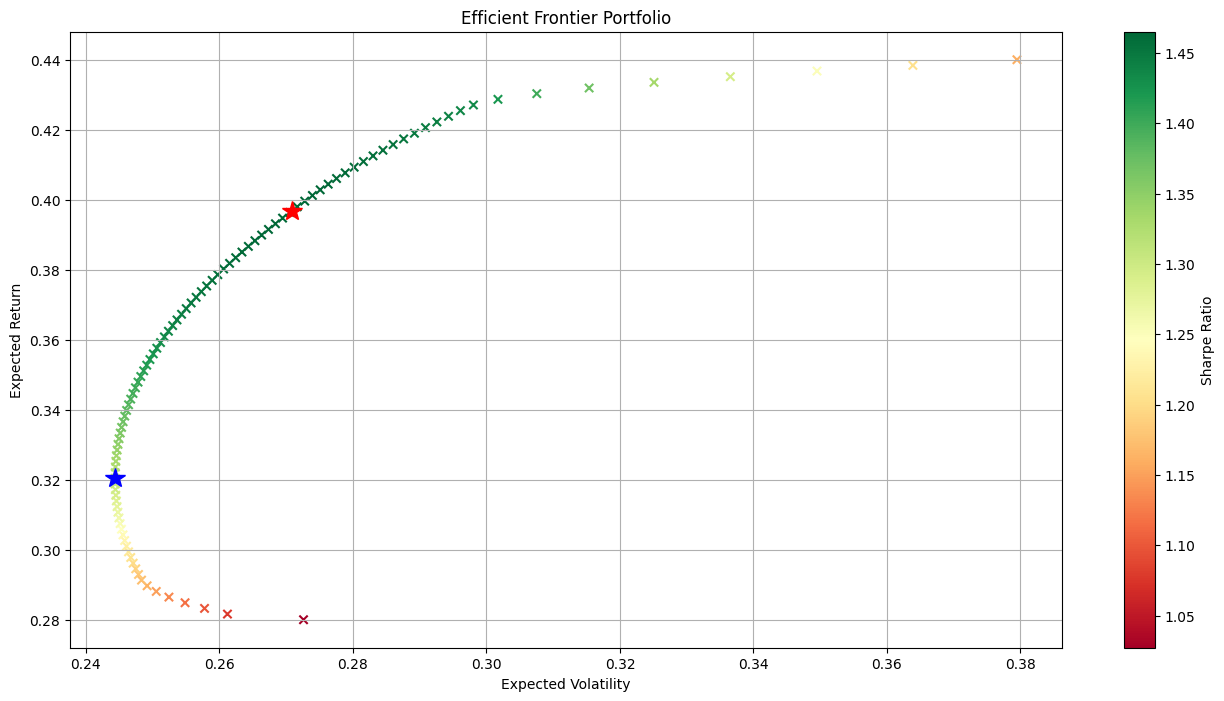

In [53]:
# Visualize the simulated portfolio for risk and return
fig = plt.figure()
ax = plt.axes()
ax.set_title('Efficient Frontier Portfolio')

# Efficient Frontier
fig.colorbar(ax.scatter(targetvols, targetrets, c=targetrets / targetvols, marker='x', cmap='RdYlGn'), label='Sharpe Ratio')

# Maximum Sharpe Portfolio
ax.plot(portfolio_stats(opt_sharpe['x'])[1], portfolio_stats(opt_sharpe['x'])[0], 'r*', markersize=15.0)

# Minimum Variance Portfolio
ax.plot(portfolio_stats(opt_var['x'])[1], portfolio_stats(opt_var['x'])[0], 'b*', markersize=15.0)
ax.set_xlabel('Expected Volatility')
ax.set_ylabel('Expected Return')
ax.grid(True)


# References

Yves Hilpisch (2018), Python For Finance: Analyze Big Financial Data